In [15]:
import numpy as np
import tools
import matplotlib.pyplot as plt
import constrct_atmosphere as CA
from scipy.integrate import cumulative_trapezoid

In [8]:
# Parameters for GJ 436b
Mp = 22.1*tools.ME  # Planet mass in [kg]
rp = 0.37*tools.RJ  # Planet radius in [m]
mu_hs = 2.35  # mean molecular weight of the bolometric heated region, assumed to be fully molecular
mu_wind = 1.08 # mean molecular weight of the wind, assumed to be fully ionised and atomic
T_eq = 700 # eqilibrium temperature in [K]

sigma_XUV = 1.89e-22 # The cross-section to XUV radiation in [m^2]
eff = 0.1 # efficiency of the energy-limited mass-loss, [unitless]
kappa_IR = 0.001 # opacity at the photosphere in [m^2/kg]
FXUV = 0.45 # The XUV flux received by the planet in [W/m^2].


vs_eq = CA.get_vs(T_eq,mu_hs)
rho_p = CA.get_rho_p(rp,Mp,kappa_IR,vs_eq)

rXUV, vs_wind, T_wind, rs_wind, Mdot = CA.solve_atmosphere(rp, Mp, FXUV, eff, mu_wind, vs_eq, rho_p, sigma_XUV)

In [14]:
# Define the radial domain array 'r':
# Start the array at planet's radius
# and extend it far past the sonic point (e.g., 8 * RJ)
r_start = 1*rp
r_end = 10*rp

# Create 250 logarithmically spaced points between the start and end radii
# This ensures good resolution near the planet (subsonic region) and far out.
r_range = np.logspace(np.log10(r_start), np.log10(r_end), 250)

v_profile = CA.get_parker_wind(r_range, vs_wind, rs_wind)
rho_profile = Mdot / (4 * np.pi * r_range**2 * v_profile)

Calculate an array of tau at each r point from rmax down to rXUV 

In [20]:
# 1. Reverse the arrays to integrate from the top down (r_max to rXUV)

n = rho_profile/(mu_wind * tools.u) # number density array in [1/m^3]
n_rev = n[::-1] # reverse the number density array

r_rev = r_range[::-1]

# 2. Perform the cumulative integral of (n * dr)
# initial=0 ensures the array length matches your grid, setting tau=0 at the very top
col_density_rev = np.abs(cumulative_trapezoid(n_rev, r_rev, initial=0))

# 4. Multiply by cross-section and reverse back to match your original 'r' grid
tau = sigma_XUV * col_density_rev[::-1]

tau

array([4.22776601e+00, 3.84172455e+00, 3.49480372e+00, 3.18270568e+00,
       2.90163753e+00, 2.64824843e+00, 2.41957497e+00, 2.21299372e+00,
       2.02617978e+00, 1.85707074e+00, 1.70383522e+00, 1.56484535e+00,
       1.43865272e+00, 1.32396735e+00, 1.21963925e+00, 1.12464222e+00,
       1.03805969e+00, 9.59072179e-01, 8.86946398e-01, 8.21025524e-01,
       7.60720707e-01, 7.05503554e-01, 6.54899497e-01, 6.08481928e-01,
       5.65867012e-01, 5.26709102e-01, 4.90696663e-01, 4.57548672e-01,
       4.27011406e-01, 3.98855604e-01, 3.72873932e-01, 3.48878731e-01,
       3.26700011e-01, 3.06183664e-01, 2.87189866e-01, 2.69591654e-01,
       2.53273648e-01, 2.38130919e-01, 2.24067960e-01, 2.10997783e-01,
       1.98841090e-01, 1.87525544e-01, 1.76985108e-01, 1.67159450e-01,
       1.57993413e-01, 1.49436529e-01, 1.41442594e-01, 1.33969274e-01,
       1.26977753e-01, 1.20432416e-01, 1.14300566e-01, 1.08552159e-01,
       1.03159573e-01, 9.80973969e-02, 9.33422343e-02, 8.88725327e-02,
      

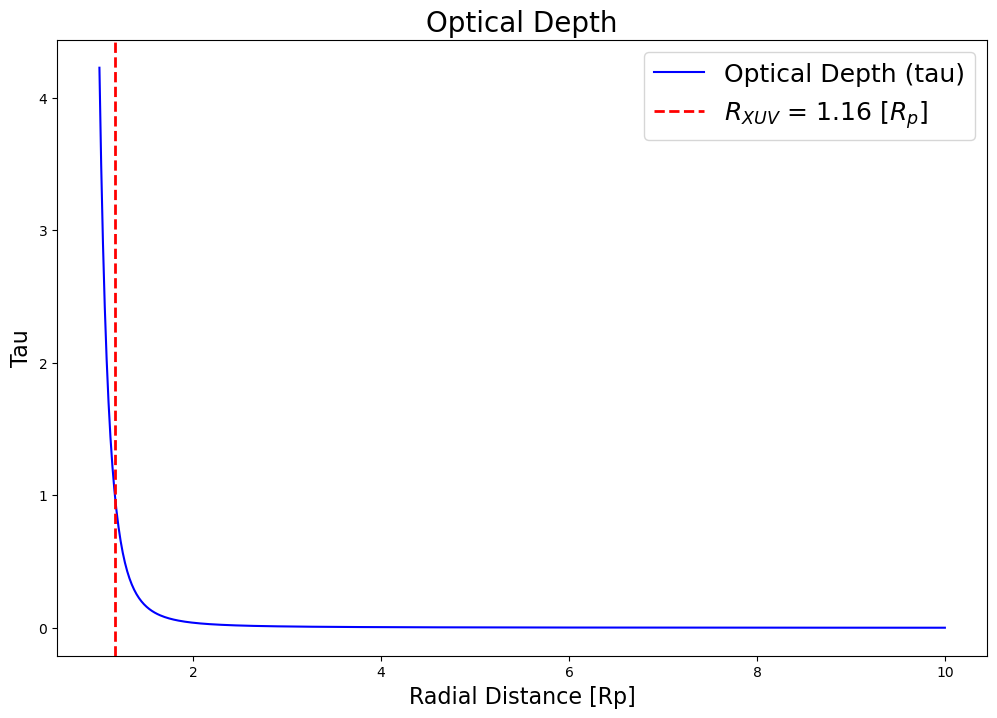

In [24]:
plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, tau, label='Optical Depth (tau)', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Optical Depth', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Tau', fontsize=16)
plt.legend(fontsize=18)
plt.show()

Compute Volumetric Heating Rate (Gamma) [W/m^3]


In [25]:
epsilon = 0.32 

Gamma = epsilon * FXUV * np.exp(-tau) * sigma_XUV * n

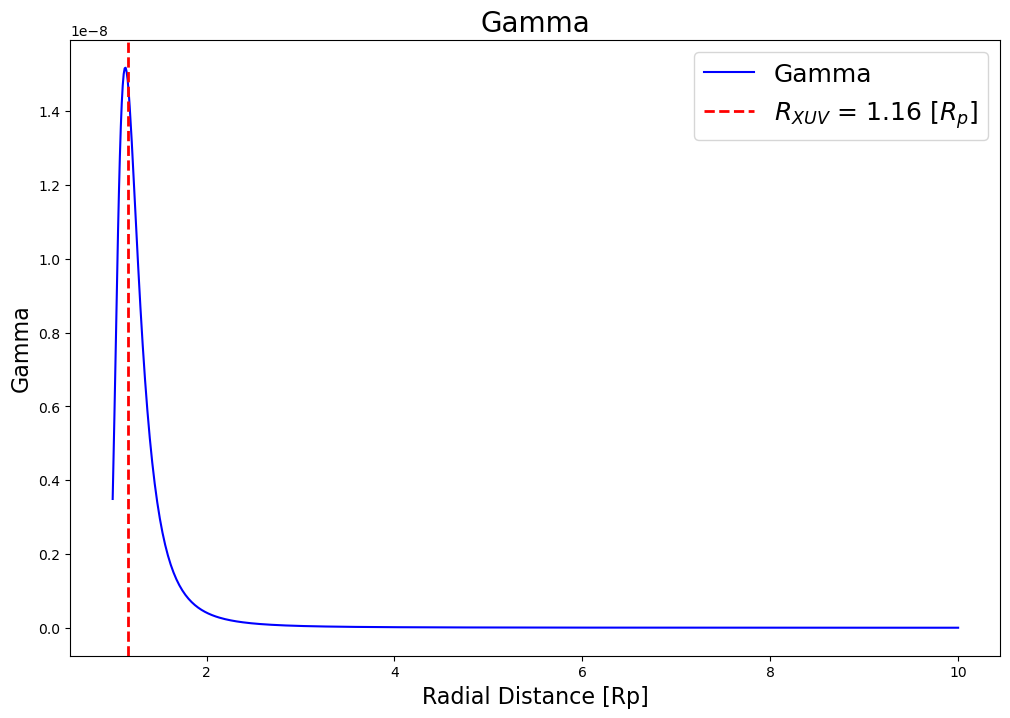

In [26]:
plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, Gamma, label='Gamma', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Gamma', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Gamma', fontsize=16)
plt.legend(fontsize=18)
plt.show()

Compute Global Heating Rate 

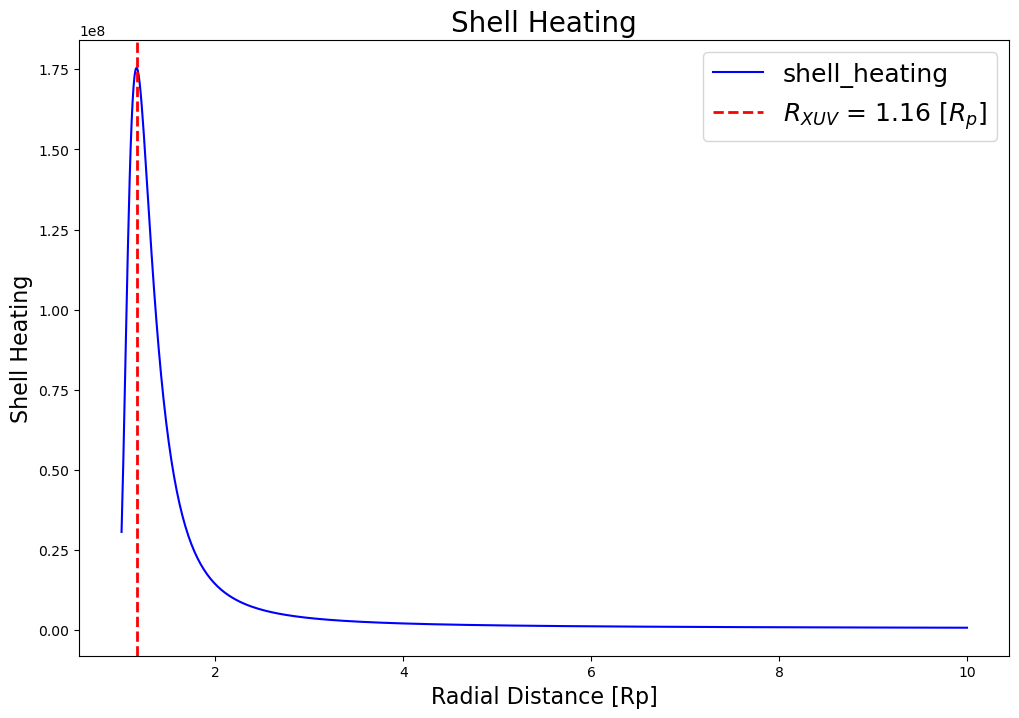

In [28]:
# Integrate Gamma * 4*pi*r^2 over the grid
shell_heating = Gamma * 4 * np.pi * r_range**2
Q_global = np.abs(np.trapezoid(shell_heating, r_range))


plt.figure(figsize=(12, 8))
plt.plot(r_range/rp, shell_heating, label='shell_heating', color='blue')
plt.axvline(rXUV/rp, color='red', linestyle='--', linewidth=2, 
            label=fr'$R_{{XUV}}$ = {round(rXUV/rp, 2)} [$R_p$]')
plt.title('Shell Heating', fontsize=20)
plt.xlabel(r'Radial Distance [Rp]', fontsize=16)
plt.ylabel(r'Shell Heating', fontsize=16)
plt.legend(fontsize=18)
plt.show()

In [29]:
Q_global


np.float64(2408506738343580.5)